In [9]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.anova_analysis.stim_belief_unit_overlap import (
    OUTPUT_PATH, WHOLE_POP, REGION_LEVEL, ALPHA as OVERLAP_ALPHA,
)

plt.rcParams.update({"font.size": 16})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fraction of units selective for stimulus only, belief only, or both -- over time

The descriptive time course behind `20260820_visualize_stim_belief_unit_overlap.ipynb`, in the style
of `scripts/figure_generation/generate_frac_var_frac_sig_plots.py`: per window, what percent of units
separate

```
A: X not chosen, X not preferred     B: X chosen, X not preferred     C: X chosen, X preferred
        \________ Run S ________/            \________ Run P ________/
         stim:  A vs B                          pref:  B vs C
```

split into three disjoint sets -- **stim only**, **pref only**, and **both**. Computed per feature,
then plotted as mean +/- s.e.m. across the 12 features, for the whole population and for each region.

Everything comes from the per-item table `stim_belief_unit_overlap.py` already writes -- one row per
(unit, feature, window) with both runs' exact permutation p-values -- so nothing here re-reads the
ANOVA grid. An item is **selective** in a run if its p-value is `<= ALPHA`. Each unit appears once per
(feature, window), so a fraction of items is a fraction of units, the same quantity
`anova_utils.num_sig_units_by_time` produces for the older ANOVAs.

**B is split, and only matters for "both".** Run S uses half of B and Run P the other half. For a
single run's selectivity that just costs power -- one contrast, which a shared B could not bias. For
"both" it is essential: a shared B puts B's sampling noise into both contrasts, which correlates their
*magnitudes* and inflates co-selectivity well above independence (null rho ~5 at alpha = 0.05, see
`20260819_run_stim_belief_unit_anova.sh`).

**Events.** Only `FeedbackOnsetLong` has an item table so far. `StimOnset` is picked up automatically
once `python3 scripts/anova_analysis/stim_belief_unit_overlap.py --trial_event StimOnset` has been run
where the grid lives.

In [10]:
# the overlap script's alpha by default. With 100 shuffles the p-value grid is 0.01, 0.02, ..., and
# 0.01 is its floor -- an item beating every one of its comparison shuffles -- which is the nearest
# match to the "99th" percentile criterion of generate_frac_var_frac_sig_plots.py. Set it to 0.01
# before putting these numbers next to those figures; at 0.05 they are not on the same scale
ALPHA = OVERLAP_ALPHA
WINDOW_SIZE = 500
TRIAL_EVENTS = ["StimOnset", "FeedbackOnsetLong"]

SAVE = False
FIG_DIR = "/data/patrick_res/figures/wcst_paper/belief_stim_single_units"

# disjoint: every selective item is in exactly one. A -> B is the stimulus step and B -> C the belief
# step, so they take the colours the repo already uses for those two variables, as in
# 20260820_coselective_example_units.ipynb. "both" is the purple of the overlap notebook
CATEGORIES = ["stim_only", "pref_only", "both"]
CATEGORY_TO_LABEL = {
    "stim_only": "stim only (A vs B)",
    "pref_only": "pref only (B vs C)",
    "both": "both",
}
CATEGORY_TO_COLOR = {
    CATEGORY_TO_LABEL["stim_only"]: visualization_utils.MODE_TO_COLOR["feature"],
    CATEGORY_TO_LABEL["pref_only"]: visualization_utils.MODE_TO_COLOR["preference"],
    CATEGORY_TO_LABEL["both"]: "tab:purple",
}

# axes as generate_frac_var_frac_sig_plots.py draws them. width is each panel's relative share, from
# that script's width_ratios=[20, 33]; the feedback panel is 6 inches, as in the overlap notebook
EVENT_CONFIG = {
    "StimOnset": {
        "ticks": [-1, -.5, 0, .5, 1], "vlines": [-.5, 0],
        "xlabel": "Time to stimuli appear (s)", "width": 20,
    },
    "FeedbackOnsetLong": {
        "ticks": [-1.5, -1, -.5, 0, .5, 1, 1.5], "vlines": [-.8, 0],
        "xlabel": "Time to feedback (s)", "width": 33,
    },
}

## Per-feature fractions

In [11]:
def load_items(trial_events=TRIAL_EVENTS, alpha=ALPHA):
    """
    The true run's per-item table for every event that has one, with the selectivity flags.

    Restricted to in_good_units, the same population as the overlap script's whole_pop: every unit
    surviving the good-units merge, including regions outside the 6 of interest.
    """
    res = []
    for event in trial_events:
        path = os.path.join(OUTPUT_PATH, f"{event}_item_pvals.pickle")
        if not os.path.exists(path):
            print(f"{event}: no item table yet -- run stim_belief_unit_overlap.py --trial_event {event}")
            continue
        items = pd.read_pickle(path)
        res.append(items[items.in_good_units])
    items = pd.concat(res, ignore_index=True)
    sig_s, sig_p = items.p_s <= alpha, items.p_p <= alpha
    items["stim_only"] = sig_s & ~sig_p
    items["pref_only"] = ~sig_s & sig_p
    items["both"] = sig_s & sig_p
    return items


def pct_sig_by_time(items, by_region=False):
    """
    Percent of units in each category per (event, window, feature[, region]).

    Subjects are pooled within a feature, as num_sig_units_by_time does, so the s.e.m. later is
    across the 12 features.
    """
    group_cols = ["trial_event", "WindowStartMilli", "feat"]
    if by_region:
        items = items[items[REGION_LEVEL].isin(REGIONS_OF_INTEREST)]
        group_cols = group_cols + [REGION_LEVEL]
    res = items.groupby(group_cols).agg(
        n_units=("PseudoUnitID", "size"),
        **{c: (c, "mean") for c in CATEGORIES},
    ).reset_index()
    res[CATEGORIES] *= 100
    # the middle of the 500 ms window, as in generate_frac_var_frac_sig_plots.py
    res["Time"] = res.WindowStartMilli / 1000 + WINDOW_SIZE / 2000
    if by_region:
        res["region"] = res[REGION_LEVEL].map(visualization_utils.REGION_TO_ABBREV)
    return res


def to_long(res):
    """One row per (cell, category), with display labels, for a hue over categories."""
    id_cols = [c for c in res.columns if c not in CATEGORIES]
    long = res.melt(id_vars=id_cols, value_vars=CATEGORIES, var_name="category", value_name="pct")
    long["category"] = long.category.map(CATEGORY_TO_LABEL)
    return long


items = load_items()
whole = pct_sig_by_time(items)
by_region = pct_sig_by_time(items, by_region=True)
REGIONS = [r for r in visualization_utils.REGION_ORDER if r in set(by_region.region)]

print(f"{len(items)} items, alpha = {ALPHA}, events: {list(items.trial_event.unique())}")
print("\nunits per (feature, window), median across cells:")
print(by_region.groupby("region").n_units.median().astype(int).reindex(REGIONS).to_string())

StimOnset: no item table yet -- run stim_belief_unit_overlap.py --trial_event StimOnset
170726 items, alpha = 0.05, events: ['FeedbackOnsetLong']

units per (feature, window), median across cells:
region
AMY     31
DSTR    35
HC      37
ITC     78
LPFC    99
ACC     33


## Plotting

In [12]:
def event_axes(res, height=3):
    """
    One panel per event present in `res`, proportioned as generate_frac_var_frac_sig_plots.py does,
    plus room on the right for the legend finish_axes puts outside the last panel.
    """
    events = [e for e in TRIAL_EVENTS if e in set(res.trial_event)]
    widths = [EVENT_CONFIG[e]["width"] for e in events]
    fig, axs = plt.subplots(
        1, len(events), figsize=(6 * sum(widths) / 33 + 2.5, height),
        sharey="row", width_ratios=widths, squeeze=False,
    )
    return fig, dict(zip(events, axs[0]))


def finish_axes(fig, axs, ylabel, title=None):
    """Event markers, ticks, a single legend outside the last panel, and the repo's formatting."""
    for i, (event, ax) in enumerate(axs.items()):
        cfg = EVENT_CONFIG[event]
        for v in cfg["vlines"]:
            ax.axvline(v, color="grey", linestyle="dotted", linewidth=3)
        ax.set_xlabel(cfg["xlabel"])
        ax.set_xticks(cfg["ticks"])
        ax.set_xticklabels(cfg["ticks"])
        ax.set_ylabel(ylabel if i == 0 else "")
        if i < len(axs) - 1 and ax.get_legend() is not None:
            ax.get_legend().remove()
    last = list(axs.values())[-1]
    if last.get_legend() is not None:
        sns.move_legend(last, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False, title=None)
        for line in last.get_legend().get_lines():
            line.set_linewidth(6)
    visualization_utils.format_plot(list(axs.values()))
    if title:
        fig.suptitle(title, fontsize=14)
    fig.tight_layout()


def save(fig, name):
    if SAVE:
        for ext in ["png", "svg"]:
            fig.savefig(os.path.join(FIG_DIR, f"{name}_alpha_{ALPHA}.{ext}"), bbox_inches="tight")


def plot_categories(res, title=None):
    """
    stim only, pref only and both on one axis.

    The dashed line is where each "only" category sits with no selectivity at all: the permutation
    p-values are uniform under the null by construction and the two runs share no trials, so an item
    lands in one run's set and not the other's with probability alpha * (1 - alpha). The same null
    puts "both" at alpha^2, which is too close to 0 to be worth a line.
    """
    long = to_long(res)
    fig, axs = event_axes(res)
    for event, ax in axs.items():
        ax.axhline(ALPHA * (1 - ALPHA) * 100, color="grey", linestyle="dashed", linewidth=2)
        sns.lineplot(
            long[long.trial_event == event], x="Time", y="pct",
            hue="category", hue_order=[CATEGORY_TO_LABEL[c] for c in CATEGORIES],
            palette=CATEGORY_TO_COLOR, linewidth=3, errorbar="se", ax=ax,
        )
    finish_axes(fig, axs, "% of units significant", title)
    return fig, axs

## Whole population

The three disjoint sets on one axis. Dashed grey is `alpha * (1 - alpha)`, where stim only and pref
only would sit with no selectivity at all. "Both" is an order of magnitude below the other two, so it
sits near the floor here; whether it exceeds what independence predicts is the overlap notebook's
test, not this plot's.

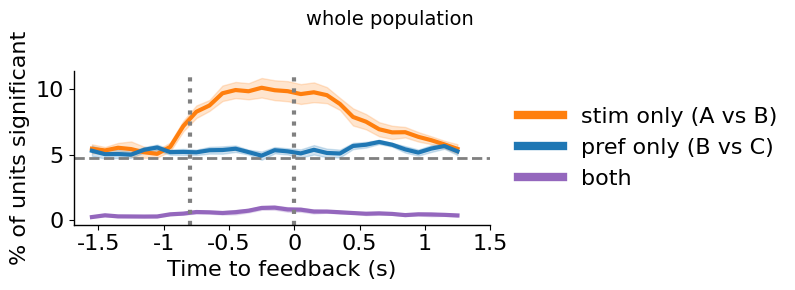

In [13]:
fig, axs = plot_categories(whole, title="whole population")
save(fig, "stim_pref_both_frac_sig_whole_pop")

## By region

The same plot for each of the 6 regions of interest. Per-region cells are a few dozen units per
feature, so "both" -- a fraction of a percent of that -- is a handful of units and noisy.

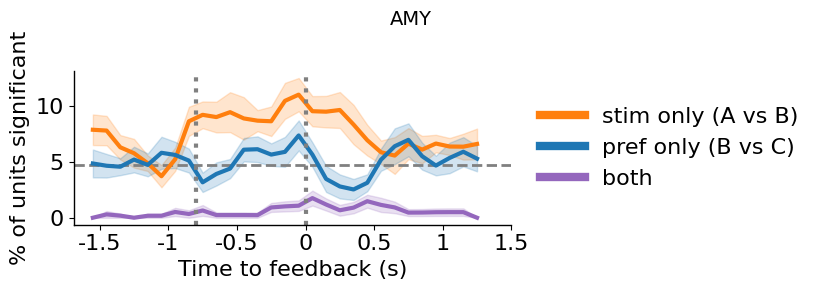

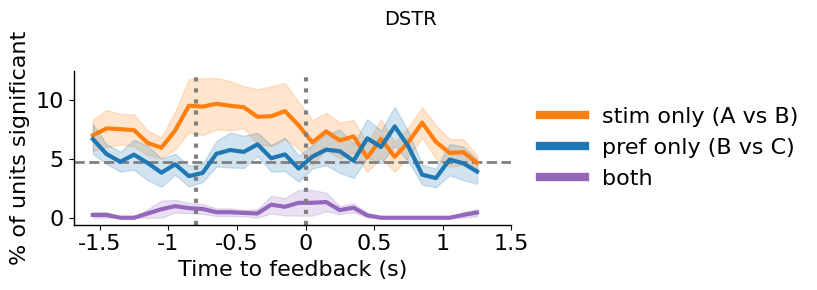

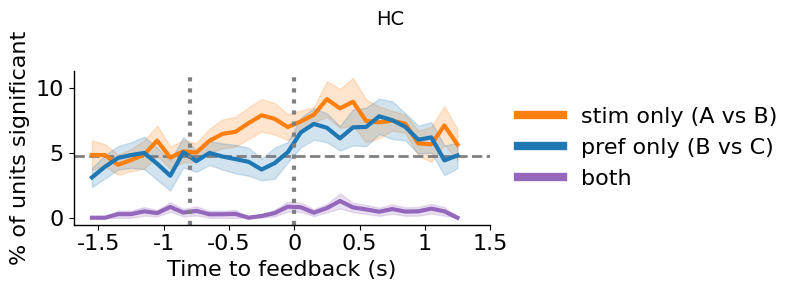

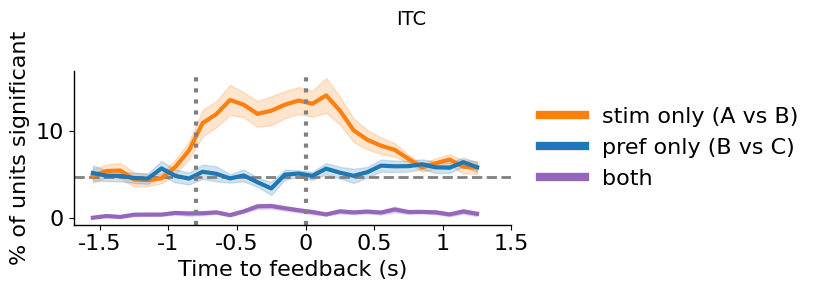

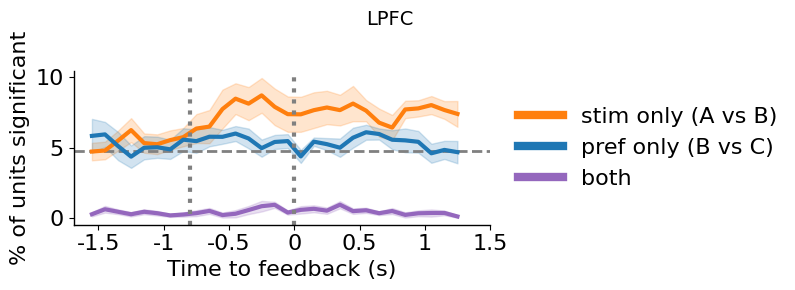

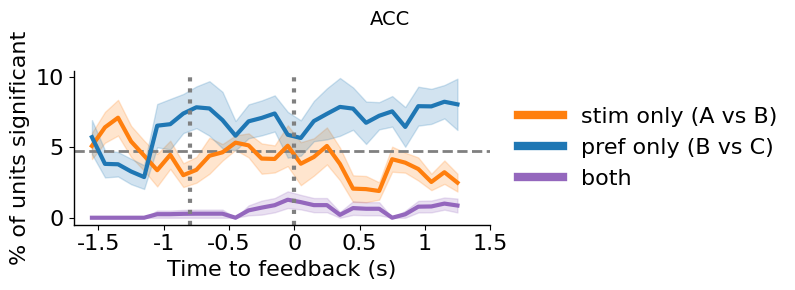

In [14]:
for region in REGIONS:
    fig, axs = plot_categories(by_region[by_region.region == region], title=region)
    save(fig, f"stim_pref_both_frac_sig_{region}")

## Cross-check against the overlap summary

`stim_belief_unit_overlap.py` stores the counts behind these sets pooled over features: `N1_`
(stim-selective), `N_1` (pref-selective) and `N11` (both) of `N` per window, so stim only is
`N1_ - N11` and pref only is `N_1 - N11`. At the overlap script's own alpha the pooled counts here
have to equal those exactly; any mismatch means the item table and the summary disagree on the
population.

The pooled percentages are not identical to the feature-averaged ones plotted above, because a mean
of ratios is not a ratio of sums, but they should be close.

In [7]:
for event in items.trial_event.unique():
    summary = pd.read_pickle(os.path.join(OUTPUT_PATH, f"{event}_overlap.pickle"))
    # every statistic's row repeats the same counts, so any one of them will do
    summary = summary[(summary.region == WHOLE_POP) & (summary.subject == "both")
                      & (summary.statistic == summary.statistic.iloc[0])].set_index("WindowStartMilli")
    expected = pd.DataFrame({
        "stim_only": summary.N1_ - summary.N11,
        "pref_only": summary.N_1 - summary.N11,
        "both": summary.N11,
        "N": summary.N,
    })

    pooled = (items[items.trial_event == event].groupby("WindowStartMilli")
              .agg(**{c: (c, "sum") for c in CATEGORIES}, N=("PseudoUnitID", "size")))
    if ALPHA == OVERLAP_ALPHA:
        match = pooled.astype(int).equals(expected.loc[pooled.index].astype(int))
        print(f"{event}: pooled counts {'match' if match else 'DO NOT match'} the overlap summary")

    averaged = whole[whole.trial_event == event].groupby("WindowStartMilli")[CATEGORIES].mean()
    table = pd.concat({
        "pooled": 100 * pooled[CATEGORIES].div(pooled.N, axis=0),
        "feature avg": averaged,
    }, axis=1).swaplevel(axis=1)[CATEGORIES]
    print(table.round(3).to_string(), "\n")

FeedbackOnsetLong: pooled counts match the overlap summary
                 stim_only             pref_only               both            
                    pooled feature avg    pooled feature avg pooled feature avg
WindowStartMilli                                                               
-1800                5.503       5.462     5.350       5.303  0.238       0.234
-1700                5.378       5.327     5.124       5.045  0.355       0.369
-1600                5.555       5.534     5.116       5.054  0.287       0.287
-1500                5.470       5.434     5.033       5.007  0.286       0.280
-1400                5.168       5.189     5.369       5.379  0.285       0.273
-1300                5.098       5.071     5.518       5.554  0.286       0.279
-1200                5.582       5.603     5.194       5.199  0.455       0.445
-1100                7.073       7.191     5.195       5.216  0.491       0.498
-1000                8.148       8.289     5.194       5.184 

---

## Caveats

- **Features are not independent samples.** The same units recur across all 12, so the s.e.m.
  across features understates the uncertainty.
- **Adjacent windows overlap by 80%** (500 ms stepped by 100 ms) -- there are only ~6-7 independent
  windows per event.
- **The two runs have very different power.** Run S detects far more than Run P, so "both" is
  bounded mainly by pref, and "stim only" is most of Run S's selective set.
- **The single-run rates are conservative.** Each run sees only half of B, so a pooled-B ANOVA would
  flag somewhat more units in each. That is the price of a valid "both".